In [4]:
import numpy as np
import os
import glob

def select(N, D, file_paths):

    selected = []
    for file_path in file_paths:
        name = os.path.basename(file_path)
        d = int(name.split("_")[3][1:])
        n = int(name.split("_")[1][1:])
        if d ==  D and  n ==  N: 
            selected.append(file_path)
    return selected

def get_chis(file_paths):
    
    chis = []
    for file_path in file_paths:
        name = os.path.basename(file_path)
        chi = int(name.split("_")[2][1:])
        if chi not in chis: chis.append(chi)

    return chis

def group_key(file_path):
    name = os.path.basename(file_path)
    l = name.split("_")
    return l[0],l[4][:-4],int(l[2][1:])

def load_data(N, D, folder_path = "data"):

    npy_files = glob.glob(os.path.join(folder_path, f"*.npy"))
    npy_files = select(N=N, D=D, file_paths=npy_files)
    
    chis = get_chis(npy_files)
    data = {group_key(file_path): np.load(file_path) for file_path in npy_files}
    return chis, data

In [5]:
def plot_data(N, D, data_path='data'):
    
    import matplotlib.pyplot as plt
    chis, data = load_data(N, D, data_path)

    # Plot the data
    for i, chi in enumerate(sorted(chis, reverse=True)):

        entropy = data.get(('entropies','simple-mps',chi))
        error = data.get(('errors','simple-mps',chi))
        if entropy is not None and error is not None:
            
            M = len(entropy)
            
            plt.plot(
                entropy,
                linestyle='-',
                color=f'C{i}', 
            )
            plt.fill_between(
                x=[i for i,_ in enumerate(entropy)],
                y1=entropy-3*error/2,
                y2=entropy+3*error/2,
                color=f'C{i}',
                alpha=0.2,
            )
        
        entropy = data.get(('entropies','stab-mps',chi))
        error = data.get(('errors','stab-mps',chi))
        if entropy is not None and error is not None:
            
            M = len(entropy)

            plt.errorbar(
                x=[i for i,_ in enumerate(entropy)],
                y=entropy,
                yerr=3*error,
                color=f'C{i}', 
                fmt='o', 
                markersize=3,
                label=f'X={chi}'
            )

        plt.hlines(
            y=np.log(chi), 
            xmin=0, 
            xmax=M,
            colors=f'C{i}',
            alpha=0.2, 
            linestyle='--',
        )

    # Labels and title
    plt.xlabel("m")
    plt.ylabel("Entropy")
    plt.title(f"N={N}, D={D}")

    plt.legend(loc='lower right')

    # Show the plot
    plt.show()

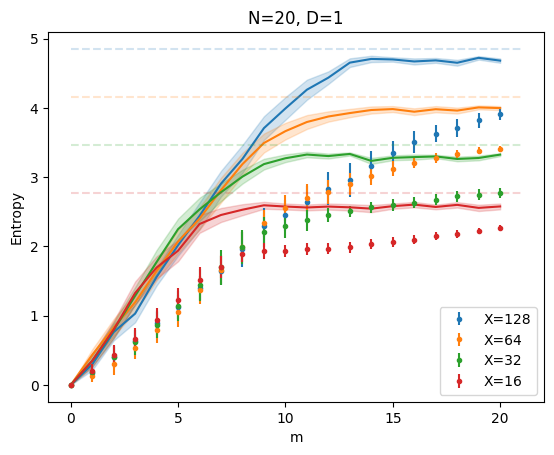

In [38]:
plot_data(N=20,D=1)

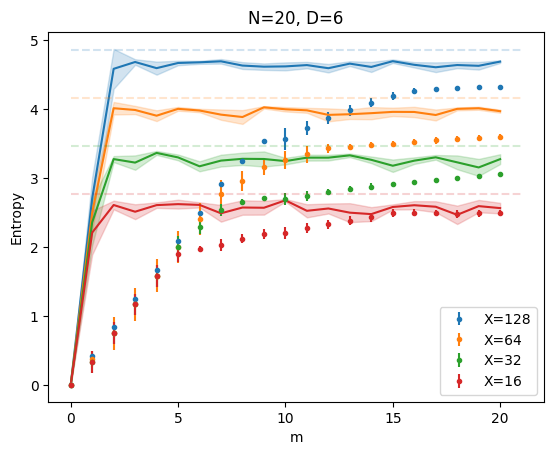

In [53]:
plot_data(N=20,D=6)